# Boundary detection across pages: which layout clusters appear near empty pages?

Structural boundaries in archival inventories often manifest as *empty pages*: a blank
verso or recto half where a new document starts on the next page, or a run of blank scans
at the start of a bound volume.

This notebook uses `archival_structures.analysis.boundary_detection` to:

1. Detect empty pages with `is_empty_page` (zero or near-zero text content).
2. Build a page sequence with `build_page_sequence`, combining page-layout cluster labels
   and empty-page flags in corpus order.
3. Analyse which layout clusters appear near empty pages via
   `empty_page_neighbor_clusters` and `empty_page_transitions`.

Two contrasting corpora:

- **`NL-HaNA_2.10.50_1`** (table register): a small cluster of empty pages at the front
  of the volume (cover and front matter).
- **`NL-AsnDA_0114.11_1`** (notary deeds): ~21% empty pages -- one blank recto half per
  two-page opening, by the typical notarial layout convention.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.analysis.boundary_detection import (
    is_empty_page, build_page_sequence, empty_page_neighbor_clusters, empty_page_transitions,
)

CORPORA = {
    'NL-HaNA_2.10.50_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'thumb_dir': Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'label': 'table register',
    },
    'NL-AsnDA_0114.11_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'thumb_dir': Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'label': 'notary deeds',
    },
}
for info in CORPORA.values():
    assert info['pagexml_dir'].exists(), info['pagexml_dir']
    assert info['thumb_dir'].exists(), info['thumb_dir']


## Load all pages, including empty ones

Unlike the layout-clustering demos, we keep *all* pages here -- the empty ones are the
signal, not noise to filter away.

In [2]:
def load_scans(pagexml_dir, n=30):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]

def split_via_width_groups(scans):
    structure = classify_inventory_structure(scans)
    print(f'  structure: {structure.structure_type} {structure.type_counts}')
    return split_inventory_into_pages(scans, structure=structure)

def split_via_gap_heuristic(scans):
    median_width = compute_corpus_median_width(scans)
    pages = []
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            features = get_opening_features(scan, corpus_median_width=median_width)
            verso, recto = split_scan(scan, features.separation_point)
            pages += [verso, recto]
        else:
            pages.append(scan)
    return pages

for inv_num, info in CORPORA.items():
    print(inv_num)
    info['scans'] = load_scans(info['pagexml_dir'])
    info['scans_by_id'] = {scan.id: scan for scan in info['scans']}
    split_fn = split_via_width_groups if inv_num == 'NL-HaNA_2.10.50_1' else split_via_gap_heuristic
    info['all_pages'] = split_fn(info['scans'])
    info['page_by_id'] = {page.id: page for page in info['all_pages']}
    n_empty = sum(1 for p in info['all_pages'] if is_empty_page(p))
    print(f'  {len(info["scans"])} scans -> {len(info["all_pages"])} pages '
          f'({n_empty} empty pages, {n_empty/len(info["all_pages"]):.0%})')


NL-HaNA_2.10.50_1


  structure: book_of_openings {'opening': 23, 'single_page': 6, 'odd_shaped': 1}


  30 scans -> 53 pages (5 empty pages, 9%)
NL-AsnDA_0114.11_1


  30 scans -> 59 pages (11 empty pages, 19%)


## Distribution of empty pages in the page sequence

A bar chart over page position shows the two very different empty-page patterns at a glance:
a front-matter cluster vs. a regular every-other-page rhythm.

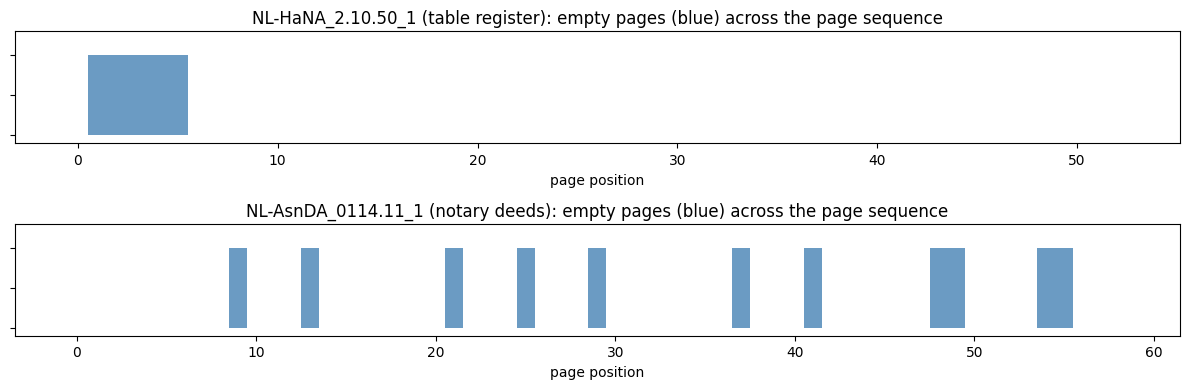

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4))
for ax, (inv_num, info) in zip(axes, CORPORA.items()):
    positions = range(len(info['all_pages']))
    empty_flags = [is_empty_page(p) for p in info['all_pages']]
    ax.bar(positions, empty_flags, width=1.0, color='steelblue', alpha=0.8)
    ax.set_title(f"{inv_num} ({info['label']}): empty pages (blue) across the page sequence")
    ax.set_xlabel('page position')
    ax.set_ylim(-0.1, 1.3)
    ax.yaxis.set_ticklabels([])
plt.tight_layout()
plt.show()


## Cluster page layouts (non-empty pages only)

`GridPattern` requires at least one text line, so we cluster only pages with real content.
The resulting cluster labels are joined back into the full sequence.

In [4]:
for inv_num, info in CORPORA.items():
    pages_with_text = [p for p in info['all_pages'] if len(p.get_lines()) > 0]
    clusters, gp = cluster_page_layouts(pages_with_text, unit_size=50, pattern_size=3,
                                         min_cluster_size=4)
    info['page_clusters'] = clusters
    n_clusters = clusters.nunique() - (1 if -1 in clusters.values else 0)
    print(f'{inv_num} ({info["label"]}): {len(pages_with_text)} pages with text, '
          f'{n_clusters} layout clusters, {(clusters == -1).mean():.0%} noise')
    print(clusters.value_counts().sort_index())
    print()


done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 48 docs, with 100 x and 114 y points
took 0.0 seconds (total: 0.0)


done computing patterns, 345 distinct patterns
took 0.6 seconds (total: 0.6)
done computing tf-idf of patterns
took 0.0 seconds (total: 0.6)
NL-HaNA_2.10.50_1 (table register): 48 pages with text, 0 layout clusters, 100% noise
cluster
-1    48
Name: count, dtype: int64

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 48 docs, with 54 x and 81 y points
took 0.0 seconds (total: 0.0)


done computing patterns, 386 distinct patterns
took 0.2 seconds (total: 0.2)
done computing tf-idf of patterns
took 0.0 seconds (total: 0.2)
NL-AsnDA_0114.11_1 (notary deeds): 48 pages with text, 2 layout clusters, 44% noise
cluster
-1    21
 0    16
 1    11
Name: count, dtype: int64



## Build the page sequence

`build_page_sequence` assembles the full sequence with cluster labels and empty-page flags.

In [5]:
for inv_num, info in CORPORA.items():
    seq = build_page_sequence(info['all_pages'], info['page_clusters'])
    info['sequence'] = seq
    print(f'{inv_num}: {len(seq)} pages, {seq["is_empty"].sum()} empty')
    print(seq[['page_id', 'cluster', 'is_empty', 'position']].head(10).to_string(index=False))
    print('...')
    print()


NL-HaNA_2.10.50_1: 53 pages, 5 empty
                         page_id cluster  is_empty  position
      NL-HaNA_2.10.50_1_0001.jpg      -1     False         0
NL-HaNA_2.10.50_1_0002.jpg-verso    <NA>      True         1
NL-HaNA_2.10.50_1_0002.jpg-recto    <NA>      True         2
NL-HaNA_2.10.50_1_0003.jpg-verso    <NA>      True         3
NL-HaNA_2.10.50_1_0003.jpg-recto    <NA>      True         4
NL-HaNA_2.10.50_1_0004.jpg-verso    <NA>      True         5
NL-HaNA_2.10.50_1_0004.jpg-recto      -1     False         6
      NL-HaNA_2.10.50_1_0005.jpg      -1     False         7
NL-HaNA_2.10.50_1_0006.jpg-verso      -1     False         8
NL-HaNA_2.10.50_1_0006.jpg-recto      -1     False         9
...

NL-AsnDA_0114.11_1: 59 pages, 11 empty
                          page_id cluster  is_empty  position
      NL-AsnDA_0114.11_1_0001.jpg      -1     False         0
NL-AsnDA_0114.11_1_0002.jpg-verso       0     False         1
NL-AsnDA_0114.11_1_0002.jpg-recto       0     False         2


## Transition analysis: which clusters border empty pages?

`empty_page_transitions` gives the immediate before/after cluster for each empty page.
`empty_page_neighbor_clusters` broadens this to a ±3-page window.

In [6]:
for inv_num, info in CORPORA.items():
    neighbors = empty_page_neighbor_clusters(info['sequence'], window=3)
    before, after = empty_page_transitions(info['sequence'])
    info['empty_neighbors'] = neighbors
    info['before_empty'] = before
    info['after_empty'] = after
    print(f'=== {inv_num} ({info["label"]}) ===')
    print('\nLayout clusters within 3 pages of an empty page:')
    if not neighbors.empty:
        print(neighbors.groupby(['rel_position', 'cluster']).size()
              .reset_index(name='count').to_string(index=False))
    print('\nLayout cluster immediately BEFORE each empty page (n occurrences):')
    print(before.to_string() if not before.empty else '  (none)')
    print('\nLayout cluster immediately AFTER each empty page (n occurrences):')
    print(after.to_string() if not after.empty else '  (none)')
    print()


=== NL-HaNA_2.10.50_1 (table register) ===

Layout clusters within 3 pages of an empty page:
 rel_position  cluster  count
           -3       -1      1
           -2       -1      1
           -1       -1      1
            1       -1      1
            2       -1      2
            3       -1      3

Layout cluster immediately BEFORE each empty page (n occurrences):
cluster
-1    5

Layout cluster immediately AFTER each empty page (n occurrences):
cluster
-1    5

=== NL-AsnDA_0114.11_1 (notary deeds) ===

Layout clusters within 3 pages of an empty page:
 rel_position  cluster  count
           -3       -1      7
           -3        0      1
           -3        1      3
           -2       -1      5
           -2        0      4
           -2        1      2
           -1       -1      4
           -1        0      5
            1       -1      7
            1        0      2
            2       -1      4
            2        0      3
            2        1      4
            3    

## 5-page window thumbnails around a sample empty page

Each corpus gets a thumbnail strip centred on a sample empty page (red border), making the
page-sequence context concrete.

=== NL-HaNA_2.10.50_1 (table register) ===
  showing window around empty page at position 3


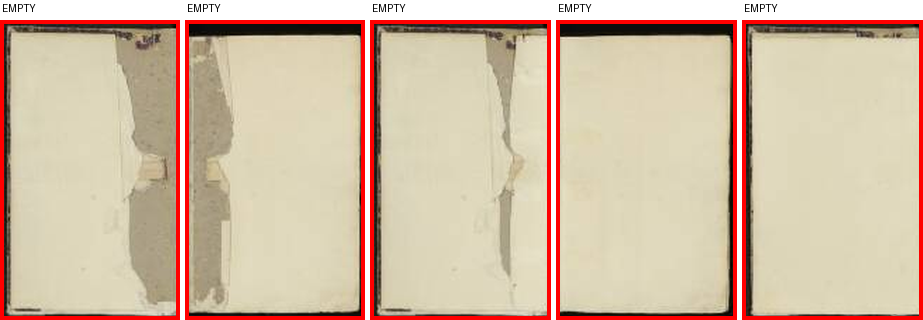

=== NL-AsnDA_0114.11_1 (notary deeds) ===
  showing window around empty page at position 37


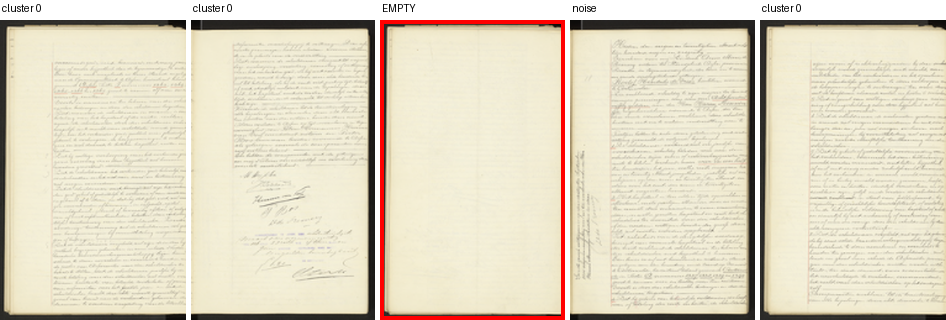

In [7]:
def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id

def find_thumbnail(thumb_dir, scan_id):
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))

def page_thumbnail(page, info):
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(info['thumb_dir'], scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = info['scans_by_id'][scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))

from IPython.display import display

def show_page_window(info, empty_position, window=2, thumb_h=300):
    # Thumbnail strip centred on the empty page at empty_position.
    seq = info['sequence']
    positions = range(max(0, empty_position - window),
                      min(len(info['all_pages']), empty_position + window + 1))
    images, labels = [], []
    for pos in positions:
        page = info['all_pages'][pos]
        try:
            im = page_thumbnail(page, info)
        except StopIteration:
            continue
        scale = thumb_h / im.height
        im = im.resize((round(im.width * scale), thumb_h), Image.LANCZOS)
        row = seq.loc[seq['position'] == pos].iloc[0]
        if row['is_empty']:
            draw = ImageDraw.Draw(im)
            draw.rectangle([0, 0, im.width-1, im.height-1], outline='red', width=4)
        cl = info['page_clusters'].get(page.id, None)
        label = 'EMPTY' if row['is_empty'] else (
            'noise' if cl == -1 else f'cluster {cl}' if cl is not None else '?'
        )
        images.append(im)
        labels.append(label)
    if not images:
        return None
    total_w = sum(im.width for im in images) + 5 * (len(images) - 1)
    strip = Image.new('RGB', (total_w, thumb_h + 20), 'white')
    draw = ImageDraw.Draw(strip)
    x = 0
    for im, label in zip(images, labels):
        strip.paste(im, (x, 20))
        draw.text((x + 2, 2), label, fill='black')
        x += im.width + 5
    return strip

for inv_num, info in CORPORA.items():
    print(f'=== {inv_num} ({info["label"]}) ===')
    empty_positions = list(info['sequence'].loc[info['sequence']['is_empty'], 'position'])
    if not empty_positions:
        print('  no empty pages found')
        continue
    sample_pos = empty_positions[len(empty_positions) // 2]
    print(f'  showing window around empty page at position {sample_pos}')
    strip = show_page_window(info, sample_pos, window=2)
    if strip is not None:
        display(strip)


## Summary

The two corpora show very different boundary patterns:

- `NL-HaNA_2.10.50_1` (table register): the few empty pages are front-matter blanks.
  The layout cluster appearing immediately *after* these blanks is the dominant table
  layout cluster -- empty pages mark the start of the substantive content.
- `NL-AsnDA_0114.11_1` (notary deeds): empty pages occur every other page throughout.
  The before/after cluster distributions are roughly symmetric (one side of every deed
  opening is blank by convention), confirming structural regularity rather than rare
  exceptional boundaries.

These results complement the within-page boundary detection in
`boundary-within-pages-demo.ipynb`: the two notebooks together identify boundaries at
two scales -- within-page whitespace gaps and between-page sequence breaks.